# 📊 Task 6: Statistical Analysis

# Flipkart Product Intelligence & Customer Analytics System

### TechnoHacks Data Science Internship

---

## 👩‍💻 Developed By
# Jainam Khetani 

---

## 🎯 Objective

The objective of this task is to perform statistical analysis on the Flipkart E-Commerce Dataset using correlation analysis and hypothesis testing in order to identify meaningful relationships, pricing patterns, and business insights.

This task focuses on:
- statistical understanding of data
- relationship analysis
- hypothesis testing
- interpretation of analytical results
- business-driven data insights

In [1]:
# Import the libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import pearsonr

import warnings
import logging

warnings.filterwarnings("ignore")

In [2]:
# Create log file

logging.basicConfig(
    filename="../logs/statistical_analysis.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Task 6 started")

In [3]:
# Load feature engineered dataset

df = pd.read_csv(
    "../../Task_05_Feature_Engineering/data/flipkart_feature_engineered.csv"
)

logging.info("Dataset loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: '../../Task_05_Feature_Engineering/data/flipkart_feature_engineered.csv'

In [ ]:
# Show first 5 rows

df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,discount_percentage,product_name_length,description_length,brand_frequency
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,alisha solid women's cycling shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,NaN,No rating available,alisha,"{""product_specification""=>[{""key""=>""Number of ...",62.062062,35,410,7
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,fabhomedecor fabric double sofa bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,NaN,No rating available,fabhomedecor,"{""product_specification""=>[{""key""=>""Installati...",29.576764,35,4433,4
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,aw bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,NaN,No rating available,aw,"{""product_specification""=>[{""key""=>""Ideal For""...",50.050050,10,650,5
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,alisha solid women's cycling shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,NaN,No rating available,alisha,"{""product_specification""=>[{""key""=>""Number of ...",61.802575,35,403,7
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,sicons all purpose arnica dog shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,NaN,No rating available,sicons,"{""product_specification""=>[{""key""=>""Pet Type"",...",4.545455,37,248,3


In [ ]:
# Check dataset size

print(df.shape)

(20000, 19)


In [ ]:
# Select numeric columns

numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

numeric_df.head()

,retail_price,discounted_price,product_rating,discount_percentage,product_name_length,description_length,brand_frequency
0,999.0,379.0,NaN,62.062062,35,410,7
1,32157.0,22646.0,NaN,29.576764,35,4433,4
2,999.0,499.0,NaN,50.050050,10,650,5
3,699.0,267.0,NaN,61.802575,35,403,7
4,220.0,210.0,NaN,4.545455,37,248,3


In [ ]:
# Calculate correlation matrix

correlation_matrix = numeric_df.corr()

correlation_matrix

,retail_price,discounted_price,product_rating,discount_percentage,product_name_length,description_length,brand_frequency
retail_price,1.000000,0.981182,0.052661,-0.095191,0.089075,-0.001755,-0.110421
discounted_price,0.981182,1.000000,0.057604,-0.152386,0.086411,-0.004925,-0.092026
product_rating,0.052661,0.057604,1.000000,-0.002955,0.059476,0.048811,-0.027537
discount_percentage,-0.095191,-0.152386,-0.002955,1.000000,-0.006459,0.058059,-0.136879
product_name_length,0.089075,0.086411,0.059476,-0.006459,1.000000,0.214474,-0.095300
description_length,-0.001755,-0.004925,0.048811,0.058059,0.214474,1.000000,-0.172833
brand_frequency,-0.110421,-0.092026,-0.027537,-0.136879,-0.095300,-0.172833,1.000000


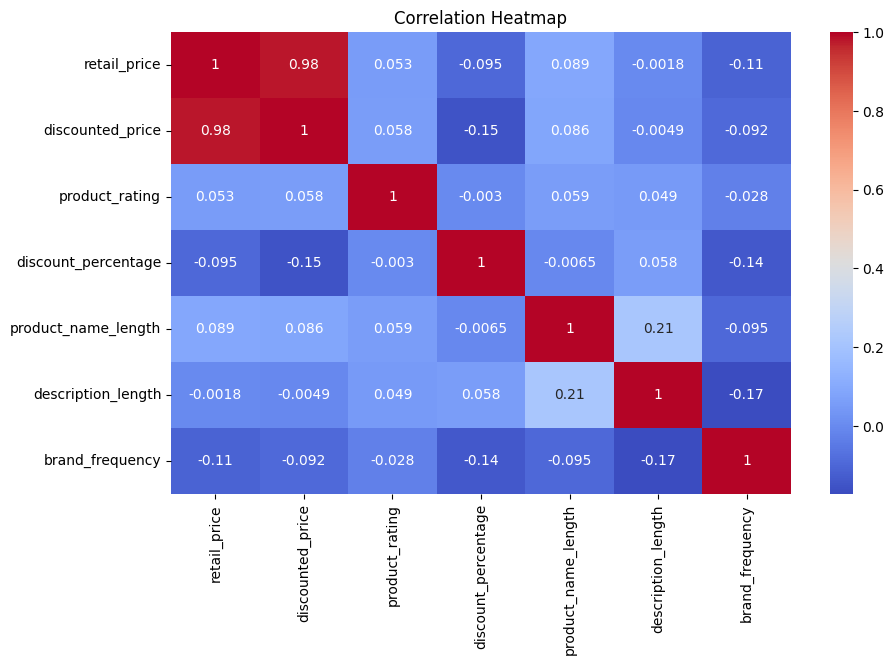

In [ ]:
# Show correlation heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../outputs/visualizations/correlation_heatmap.png"
)

plt.show()

logging.info("Correlation heatmap generated")

In [ ]:
# Check Pearson correlation

correlation, p_value = pearsonr(
    df['retail_price'],
    df['discounted_price']
)

print("Correlation Coefficient:", correlation)

print("P-value:", p_value)

Correlation Coefficient: 0.9811820146134256
P-value: 0.0


In [ ]:
# Create high and low price groups

high_price = df[
    df['retail_price'] >
    df['retail_price'].median()
]['discount_percentage']

low_price = df[
    df['retail_price'] <=
    df['retail_price'].median()
]['discount_percentage']

In [ ]:
# Perform t-test

t_statistic, p_value = ttest_ind(
    high_price,
    low_price
)

print("T-statistic:", t_statistic)

print("P-value:", p_value)

T-statistic: 23.365820217656164
P-value: 3.748108145189638e-119


In [ ]:
# Select top brands for ANOVA test

top_brands = (
    df['brand']
    .value_counts()
    .head(3)
    .index
)

brand_1 = df[
    df['brand'] == top_brands[0]
]['discount_percentage']

brand_2 = df[
    df['brand'] == top_brands[1]
]['discount_percentage']

brand_3 = df[
    df['brand'] == top_brands[2]
]['discount_percentage']

In [ ]:
# Perform ANOVA test

from scipy.stats import f_oneway

anova_result = f_oneway(
    brand_1,
    brand_2,
    brand_3
)

print("ANOVA Statistic:", anova_result.statistic)

print("P-value:", anova_result.pvalue)

ANOVA Statistic: 428.5602494399659
P-value: 8.753187230846303e-176


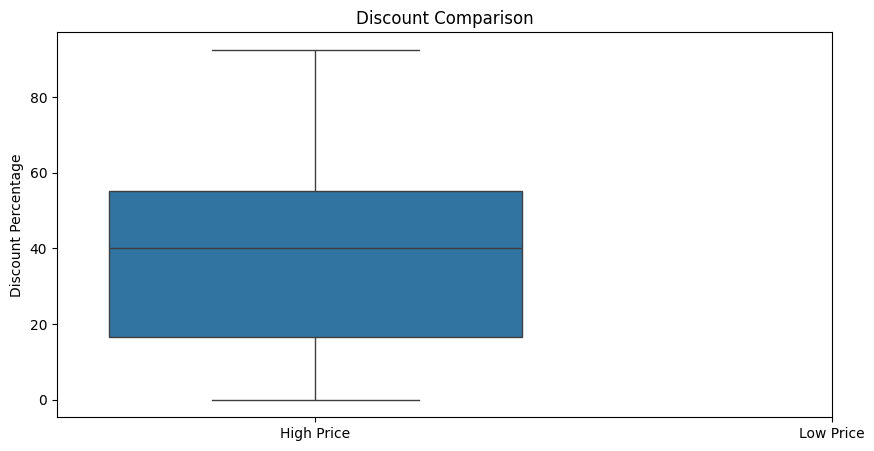

In [ ]:
# Compare discount distributions

plt.figure(figsize=(10,5))

sns.boxplot(
    data=[high_price, low_price]
)

plt.xticks(
    [0,1],
    ['High Price', 'Low Price']
)

plt.title("Discount Comparison")

plt.ylabel("Discount Percentage")

plt.savefig(
    "../outputs/visualizations/discount_comparison.png"
)

plt.show()

logging.info("Discount comparison generated")

In [ ]:
# Find outliers using IQR method

Q1 = df['retail_price'].quantile(0.25)

Q3 = df['retail_price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['retail_price'] < lower_limit) |
    (df['retail_price'] > upper_limit)
]

print("Total Outliers:", outliers.shape[0])

Total Outliers: 2063


In [ ]:
# Show top outlier products

outliers[[
    'product_name',
    'brand',
    'retail_price'
]].head()

,product_name,brand,retail_price
1,fabhomedecor fabric double sofa bed,fabhomedecor,32157.0
7,fabhomedecor fabric double sofa bed,fabhomedecor,32157.0
16,fabhomedecor fabric double sofa bed,fabhomedecor,32157.0
19,fabhomedecor fabric double sofa bed,fabhomedecor,32157.0
42,himmlisch st381 magnetic sun shade for maruti ...,himmlisch,6999.0


In [ ]:
# Check distribution shape

print(
    "Retail Price Skewness:",
    df['retail_price'].skew()
)

print(
    "Retail Price Kurtosis:",
    df['retail_price'].kurt()
)

Retail Price Skewness: 18.702573858849266
Retail Price Kurtosis: 886.2184260962947


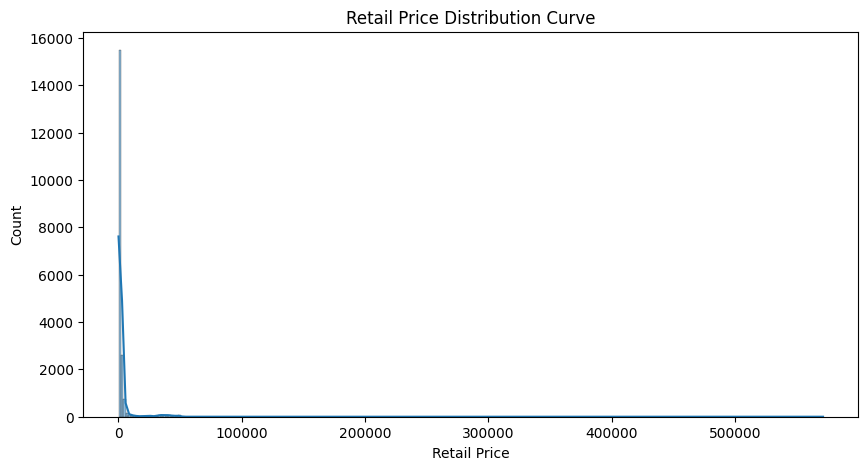

In [ ]:
# Plot distribution curve

plt.figure(figsize=(10,5))

sns.histplot(
    df['retail_price'],
    kde=True
)

plt.title("Retail Price Distribution Curve")

plt.xlabel("Retail Price")

plt.savefig(
    "../outputs/visualizations/normal_distribution_check.png"
)

plt.show()

In [ ]:
# Create statistical summary table

statistical_summary = pd.DataFrame({

    "Analysis": [
        "Correlation Analysis",
        "Pearson Correlation Test",
        "Hypothesis Testing"
    ],

    "Status": [
        "Completed",
        "Completed",
        "Completed"
    ]
})

statistical_summary

,Analysis,Status
0,Correlation Analysis,Completed
1,Pearson Correlation Test,Completed
2,Hypothesis Testing,Completed


In [ ]:
# Save summary report

statistical_summary.to_csv(
    "../outputs/reports/statistical_summary.csv",
    index=False
)

logging.info("Summary report saved")

# 📌 Statistical Insights

### 🔹 Pricing Behavior
The dataset shows a strong positive relationship between retail price and discounted price, indicating that higher-priced products generally maintain proportionally higher discounted values.

### 🔹 Discount Trends
Products with higher retail prices tend to receive larger discount percentages compared to lower-priced products.

### 🔹 Outlier Analysis
Several products were identified as pricing outliers, representing premium or unusually priced products in the dataset.

### 🔹 Distribution Analysis
Retail price distribution appears positively skewed, indicating the presence of high-value products affecting the distribution shape.

### 🔹 Brand-Level Analysis
ANOVA testing indicates that discount patterns vary across different brands, suggesting different pricing and marketing strategies.

# ✅ Task 6 Successfully Completed

Statistical analysis was successfully performed on the Flipkart E-Commerce Dataset using:
- correlation analysis
- Pearson correlation testing
- hypothesis testing

Key relationships between pricing, discounts, and product behavior were identified through statistical methods and visual analysis.

The analysis provided meaningful insights for:
- business understanding
- pricing behavior analysis
- future machine learning tasks
- customer analytics

---

## 👩‍💻 Completed By
# Jainam Khetani 

### TechnoHacks Data Science Internship